# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph, sample a connected subgraph, and narrate it.

In [8]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import textwrap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NetworkXGraphStore,
    NodeEmbeddingConfig,
    NodeContextConfig,
    SubgraphNarrator,
    SubgraphNarrativeConfig,
    SubgraphNarrativePrompt,
    sample_random_connected_subgraph,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure and run

In [9]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
PUBMED_ABSTRACT_INDEX = 0  # zero-based: 0 selects the first abstract
PUBMED_ABSTRACT_PATHS = sorted((ASSETS_ROOT / 'abstracts' / 'pubmed').glob('*.txt'))
if not PUBMED_ABSTRACT_PATHS:
    raise FileNotFoundError('No PubMed abstracts found.')
if not 0 <= PUBMED_ABSTRACT_INDEX < len(PUBMED_ABSTRACT_PATHS):
    raise IndexError(
        f'PUBMED_ABSTRACT_INDEX must be between 0 and {len(PUBMED_ABSTRACT_PATHS) - 1}.'
    )
ABSTRACT_PATH = PUBMED_ABSTRACT_PATHS[PUBMED_ABSTRACT_INDEX]
ASSEMBLED_ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology_assembled.yaml'
ONTOLOGY_PATH = (
    ASSEMBLED_ONTOLOGY_PATH
    if ASSEMBLED_ONTOLOGY_PATH.exists()
    else ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
)
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'
LLM_PROVIDER = 'openai'  # choose 'openai' or 'ollama'
LLM_MODEL = 'gpt-4o-mini' if LLM_PROVIDER == 'openai' else 'gemma4:12b-mlx' # 'gpt-4o-mini' 'gpt-5-nano'
LLM_OPTIONS = (
    {'max_output_tokens': 16384}
    if LLM_PROVIDER == 'openai'
    else {'num_ctx': 32768, 'num_predict': -1}
)
NARRATIVE_COLUMNS = 80
EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2'
from sentence_transformers import SentenceTransformer
EMBEDDING_MODEL = SentenceTransformer(EMBEDDING_MODEL_NAME)
EMBEDDING_CONFIG = NodeEmbeddingConfig(
    normalize=True,
    model_id=EMBEDDING_MODEL_NAME,
)

abstract_text = load_text(ABSTRACT_PATH)
print(textwrap.fill(abstract_text, width=NARRATIVE_COLUMNS))

ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.05
RELATION_EFFORT = 1.5
MINIMUM_ENTITY_FRACTION = 0.75
DENSITY_RETRIES = 2
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
    minimum_entity_fraction=MINIMUM_ENTITY_FRACTION,
    density_retries=DENSITY_RETRIES,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
    casting_retries=2,
)

graphicalizer = Graphicalizer.from_provider(
    ontology,
    config,
    options=LLM_OPTIONS,
    embedding_model=EMBEDDING_MODEL,
    embedding_config=EMBEDDING_CONFIG,
)
result = graphicalizer.run(abstract_text)

Title: Recurrent zoonotic transmission of Nipah virus into humans, Bangladesh,
2001-2007. PMID: 19751584 Journal: Emerging infectious diseases Publication
date: 2009Aug DOI: 10.3201/eid1508.081237 Authors: Stephen P Luby, M Jahangir
Hossain, Emily S Gurley, Be Nazir Ahmed, Shakila Banu, Salah Uddin Khan, Nusrat
Homaira, Paul A Rota, Pierre E Rollin, James A Comer, Eben Kenah, Thomas G
Ksiazek, Mahmudur Rahman  Abstract: Human Nipah outbreaks recur in a specific
region and time of year in Bangladesh. Fruit bats are the reservoir host for
Nipah virus. We identified 23 introductions of Nipah virus into human
populations in central and northwestern Bangladesh from 2001 through 2007. Ten
introductions affected multiple persons (median 10). Illness onset occurred from
December through May but not every year. We identified 122 cases of human Nipah
infection. The mean age of case-patients was 27 years; 87 (71%) died. In 62
(51%) Nipah virus-infected patients, illness developed 5-15 days after 

In [10]:
print('Model:', config.model)
print('Target entities:', density.target_counts(abstract_text)['target_entity_count'])
print('Minimum entities:', density.target_counts(abstract_text)['minimum_entity_count'])
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))
print('Embedding metadata:', result.graph.graph.get('node_context_embeddings'))

Model: gpt-4o-mini
Target entities: 11
Minimum entities: 9
Source SHA-256: 96e2f891182c947e248a52fa8650a492b541d14176f5e61f32151a20d0c4b3f6
Raw validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 9, 'edge_count': 10, 'density': 0.2777777777777778, 'max_neighbor_count': 6, 'hub_nodes': ('e2',), 'issues': ('graph contains 1 hub node(s): e2',), 'density_ok': True, 'hubs_ok': False}
Normalized validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 9, 'edge_count': 10, 'density': 0.2777777777777778, 'max_neighbor_count': 6, 'hub_nodes': ('e2',), 'issues': ('graph contains 1 hub node(s): e2',), 'density_ok': True, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 1, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9'), 'discarded_entity_ids': (), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10'), 'discarded_relation_ids': ()}
Final validation

In [ ]:
GRAPH_STORE = NetworkXGraphStore(PROJECT_ROOT / 'outputs' / 'graphs')
GRAPH_ID = f'pubmed_{PUBMED_ABSTRACT_INDEX:04d}'
GRAPH_PATH = GRAPH_STORE.save(result.graph, GRAPH_ID)
LOADED_GRAPH = GRAPH_STORE.load(GRAPH_ID)
print('Saved graph:', GRAPH_PATH)
print('Stored graphs:', len(GRAPH_STORE.list()))
print('Loaded nodes:', LOADED_GRAPH.number_of_nodes())
print('Loaded edges:', LOADED_GRAPH.number_of_edges())

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nNipah virus", shape=box];
  "e2" [label="human_host\nHumans", shape=box];
  "e3" [label="reservoir_host\nFruit bats", shape=box];
  "e4" [label="geographic_location\nBangladesh", shape=box];
  "e5" [label="clinical_entity\nNipah case-patients", shape=box];
  "e6" [label="transmission_route\nperson-to-person transmission", shape=box];
  "e7" [label="symptom_or_sign\nIllness onset", shape=box];
  "e8" [label="clinical_entity\nNipah virus-infected patients", shape=box];
  "e9" [label="prevention_measure\nInterventions", shape=box];
  "e1" -> "e5" [color="#555555", label="infects"];
  "e2" -> "e1" [color="#555555", label="causes_infection"];
  "e2" -> "e6" [color="#555555", label="transmitted_by"];
  "e2" -> "e9" [color="#555555", label="prevents"];
  "e3" -> "e1" [color="#555555", label="carried_by"];
  "e3" -> "e2" [color="#555555", label="exposes"];
  "e4" -> "e2" [color="#555555", label="occurred_in"];
  "e5" -> "e

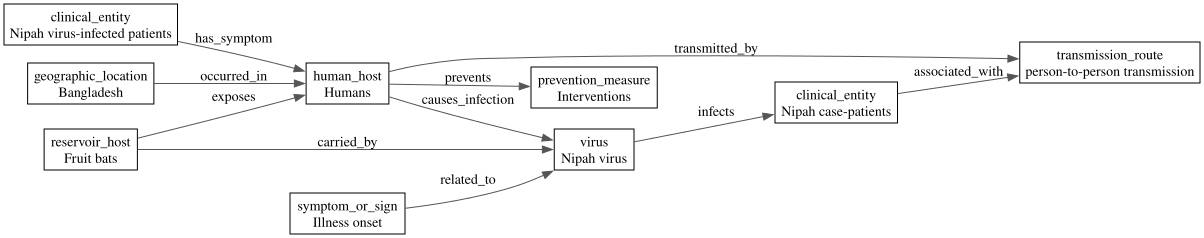

In [11]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Sample and narrate a connected subgraph

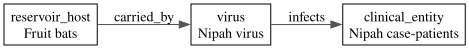

In [12]:
SUBGRAPH_NODE_COUNT = 3
SUBGRAPH_SEED = None
NARRATIVE_WORDS = 100
SUBGRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_random_subgraph.svg'
NARRATIVE_PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'subgraph_narrative_prompt_template.yaml'
NARRATIVE_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'subgraph-narrator-0.1.0.yaml'

sampled_subgraph = sample_random_connected_subgraph(
    result.typed_graph,
    num_nodes=SUBGRAPH_NODE_COUNT,
    seed=SUBGRAPH_SEED,
)
validate_ontology_labeled_graph(sampled_subgraph)
render_graph(
    sampled_subgraph,
    SUBGRAPH_OUTPUT_PATH,
    graph_name='NipahRandomSubgraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(SUBGRAPH_OUTPUT_PATH)))

In [13]:

narrator_prompt = SubgraphNarrativePrompt.from_yaml_file(NARRATIVE_PROMPT_PATH)
narrator = SubgraphNarrator.from_graphicalizer(
    graphicalizer,
    prompt=narrator_prompt,
    prompt_snapshot_path=NARRATIVE_SNAPSHOT_PATH,
)
narrative = narrator.narrate(
    sampled_subgraph,
    SubgraphNarrativeConfig(target_words=NARRATIVE_WORDS),
)
print(textwrap.fill(narrative.narrative, width=NARRATIVE_COLUMNS))
print('Requested words:', narrative.requested_words)
print('Actual words:', narrative.actual_words)
if narrative.uncertainty:
    print('Uncertainty:', narrative.uncertainty)


The **Fruit bats**, identified as a **reservoir host**, play a crucial role in
the transmission of **Nipah virus**, a significant pathogen associated with
zoonotic infections in humans. The connection is underscored by evidence that
links fruit bats as the primary carriers of the virus, facilitating its
spillover into human populations. Human infections, termed **Nipah case-
patients**, manifest severe clinical symptoms such as respiratory distress and
have been reported with a high mortality rate. This underscores the critical
relationship where **Nipah virus** **infects** these patients after being
transmitted from fruit bats, establishing a significant public health concern.
Requested words: 100
Actual words: 95
Uncertainty: All associations are well-supported by the available evidence.


## Inspect node contexts

In [ ]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {textwrap.fill(node_context.summary, width=NARRATIVE_COLUMNS)}')
    for evidence in node_context.evidence:
        print(f'  evidence: {textwrap.fill(evidence, width=NARRATIVE_COLUMNS)}')
    if node_context.uncertainty:
        print(f'  uncertainty: {textwrap.fill(node_context.uncertainty, width=NARRATIVE_COLUMNS)}')


[e1] Nipah virus is an infectious virus responsible for human cases of Nipah
infection, predominantly transmitted from fruit bats to humans and known for
causing significant morbidity and mortality.
  evidence: ...Fruit bats are the reservoir host for Nipah virus.
  evidence: ...identified 122 cases of human Nipah infection.
  uncertainty: None

[e2] Humans are hosts that can contract Nipah virus through person-to-person
transmission, particularly following close contact with infected individuals,
leading to various symptoms and high fatality rates.
  evidence: ...human Nipah outbreaks recur in a specific region...
  evidence: ...more than half of identified cases result from person-to-person transmission.
  uncertainty: None

[e3] Fruit bats serve as reservoir hosts for Nipah virus, playing a critical role in
its transmission cycle to humans and potentially other species.
  evidence: ...Fruit bats are the reservoir host for Nipah virus.
  evidence: ...more than half of identified cas